## Análise de clusters

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

### Carregando dados

In [3]:
df = pd.read_csv('dados/df_final.csv')
print(f"Dataset: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
df.head(3)

C:\Users\Will\AppData\Local\Temp\ipykernel_8396\3711658730.py:1: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT, 2: ORIGIN_AIRPORT_NAME, 3: ORIGIN_CITY, 4: ORIGIN_STATE, 5: ORIGIN_COUNTRY, 6: DEST_AIRPORT_NAME, 7: DEST_CITY, 8: DEST_STATE, 9: DEST_COUNTRY) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('dados/df_final.csv')


Dataset: 5,819,079 linhas x 46 colunas


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_COUNTRY,DEST_LATITUDE,DEST_LONGITUDE,dia_semana,hora_partida
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,Quinta,0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559,Quinta,0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313,Quinta,0


### Selecionando Features para a clusterização

Para a clusterização deve-se escolher features que capturem o comportamento operacional dos voos como:

- **Temporais:** mês, dia da semana, hora de partida
- **Operacionais:** distância, atraso na saída, atraso na chegada
- **Geográficas:** coordenadas de origem e destino

In [4]:
# Removendo voos cancelados/desviados
df_cluster = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].copy()
print(f"Voos válidos: {df_cluster.shape[0]:,}")

Voos válidos: 5,714,008


In [5]:
# Features para clustering
features_clustering = [
    'MONTH', 'DAY_OF_WEEK', 'hora_partida',
    'DISTANCE',
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY',
    'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE',
    'DEST_LATITUDE', 'DEST_LONGITUDE'
]

df_features = df_cluster[features_clustering].dropna()
print(f"Registros após remoção de nulos: {df_features.shape[0]:,}")
print(f"\nFeatures selecionadas ({len(features_clustering)}):")

for f in features_clustering:
    print(f"  - {f}")

Registros após remoção de nulos: 5,222,000

Features selecionadas (10):
  - MONTH
  - DAY_OF_WEEK
  - hora_partida
  - DISTANCE
  - DEPARTURE_DELAY
  - ARRIVAL_DELAY
  - ORIGIN_LATITUDE
  - ORIGIN_LONGITUDE
  - DEST_LATITUDE
  - DEST_LONGITUDE


In [6]:
df_features.describe().round(2)

,MONTH,DAY_OF_WEEK,hora_partida,DISTANCE,DEPARTURE_DELAY,ARRIVAL_DELAY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_LATITUDE,DEST_LONGITUDE
count,5222000.00,5222000.00,5222000.00,5222000.00,5222000.0,5222000.00,5222000.00,5222000.00,5222000.00,5222000.00
mean,6.23,3.93,13.03,825.75,9.7,4.89,36.63,-95.58,36.63,-95.58
std,3.38,1.99,4.83,608.97,37.4,39.79,6.01,18.19,6.01,18.20
min,1.00,1.00,0.00,31.00,-82.0,-87.00,13.48,-176.65,13.48,-176.65
25%,3.00,2.00,9.00,373.00,-5.0,-13.00,32.90,-111.98,32.90,-111.98
50%,6.00,4.00,13.00,651.00,-1.0,-5.00,37.24,-90.26,37.24,-90.26
75%,9.00,6.00,17.00,1067.00,8.0,8.00,40.79,-81.69,40.79,-81.69
max,12.00,7.00,23.00,4983.00,1988.0,1971.00,71.29,-64.80,71.29,-64.80


### Normalizando com StandardScaler

In [7]:
# Amostragem para viabilizar o processamento (dataset muito grande)
SAMPLE_SIZE = 100_000
np.random.seed(42)

df_sample = df_features.sample(n=SAMPLE_SIZE, random_state=42)
print(f"Amostra utilizada: {SAMPLE_SIZE:,} registros (de {len(df_features):,})")

Amostra utilizada: 100,000 registros (de 5,222,000)


In [8]:
# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

print(f"\nShape dos dados normalizados: {X_scaled.shape}")
print(f"Média: {X_scaled.mean(axis=0).round(4)}")
print(f"Desvio: {X_scaled.std(axis=0).round(4)}")


Shape dos dados normalizados: (100000, 10)
Média: [-0.  0. -0. -0.  0. -0.  0. -0.  0. -0.]
Desvio: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Definindo o número de clusters

K= 2 | Inércia:        882,546 | Silhouette: 0.1456
K= 3 | Inércia:        767,808 | Silhouette: 0.1600
K= 4 | Inércia:        711,167 | Silhouette: 0.1723
K= 5 | Inércia:        666,249 | Silhouette: 0.1121
K= 6 | Inércia:        635,606 | Silhouette: 0.1071
K= 7 | Inércia:        604,995 | Silhouette: 0.1157
K= 8 | Inércia:        581,819 | Silhouette: 0.1242
K= 9 | Inércia:        558,073 | Silhouette: 0.1097
K=10 | Inércia:        541,392 | Silhouette: 0.1152


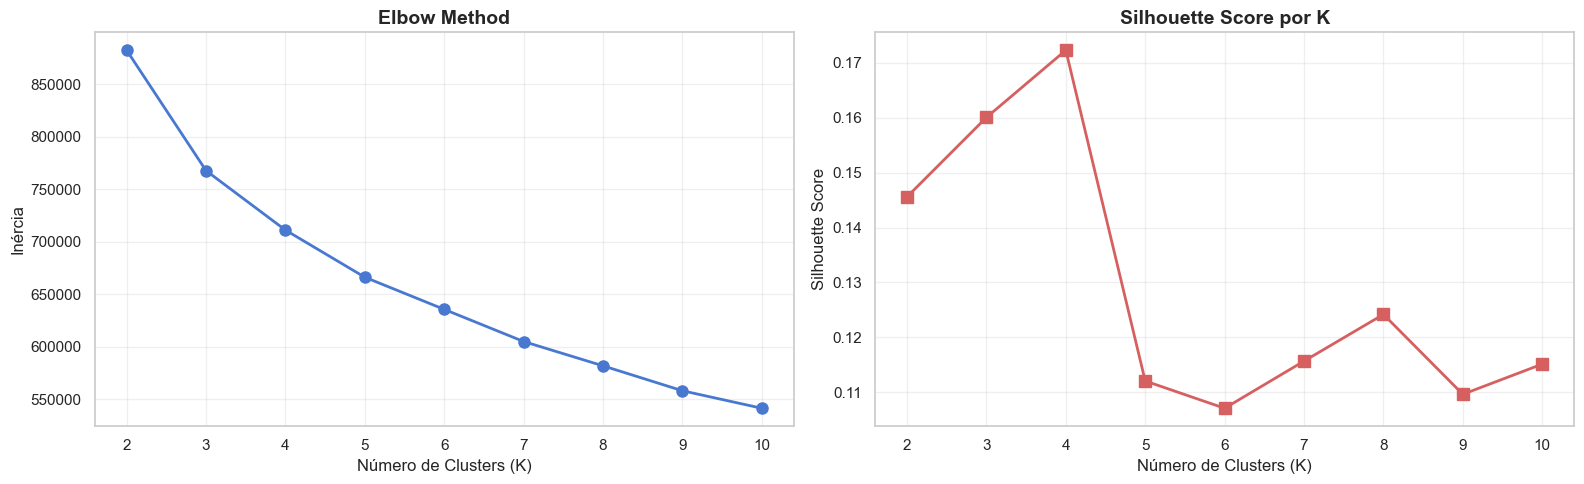


Melhor K pelo Silhouette Score: 4 (score: 0.1723)


In [9]:
# Elbow Method e Silhouette Score
K_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=10_000, random_state=42)
    silhouette_scores.append(sil)
    print(f"K={k:2d} | Inércia: {kmeans.inertia_:>14,.0f} | Silhouette: {sil:.4f}")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inércia', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score por K', fontsize=14, fontweight='bold')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k_sil = list(K_range)[np.argmax(silhouette_scores)]
print(f"\nMelhor K pelo Silhouette Score: {best_k_sil} (score: {max(silhouette_scores):.4f})")

### Aplicando o KMeans++ com o K Ideal

In [10]:
# Usar o melhor K identificado pelo Silhouette Score
OPTIMAL_K = best_k_sil
print(f"Treinando KMeans++ com K={OPTIMAL_K}...")

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,
    max_iter=300,
    random_state=42
)

df_sample = df_sample.copy()
df_sample['CLUSTER'] = kmeans_final.fit_predict(X_scaled)

sil_final = silhouette_score(X_scaled, df_sample['CLUSTER'], sample_size=10_000, random_state=42)
print(f"Silhouette Score final: {sil_final:.4f}")
print(f"Inércia final: {kmeans_final.inertia_:,.0f}")
print(f"\nDistribuição dos clusters:")
print(df_sample['CLUSTER'].value_counts().sort_index())

Treinando KMeans++ com K=4...
Silhouette Score final: 0.1723
Inércia final: 711,167

Distribuição dos clusters:
CLUSTER
0     4620
1    20223
2    58209
3    16948
Name: count, dtype: int64


### Distribuindo os clusters

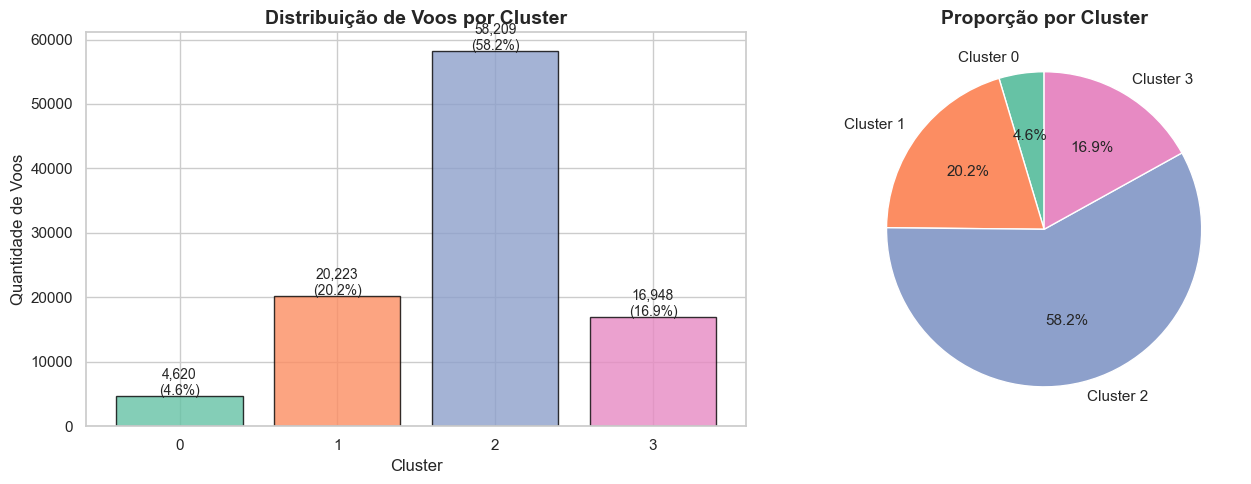

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagem
cluster_counts = df_sample['CLUSTER'].value_counts().sort_index()
colors = sns.color_palette('Set2', OPTIMAL_K)

axes[0].bar(cluster_counts.index, cluster_counts.values, color=colors, edgecolor='black', alpha=0.8)

for i, v in enumerate(cluster_counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df_sample)*100:.1f}%)', ha='center', fontsize=10)
    
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Quantidade de Voos', fontsize=12)
axes[0].set_title('Distribuição de Voos por Cluster', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(OPTIMAL_K))

# Pizza
axes[1].pie(cluster_counts.values, labels=[f'Cluster {i}' for i in cluster_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Proporção por Cluster', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Análise descritiva por cluster

In [12]:
# Estatísticas por cluster
cluster_profile = df_sample.groupby('CLUSTER')[features_clustering].agg(['mean', 'median', 'std']).round(2)
cluster_profile.columns = ['_'.join(col) for col in cluster_profile.columns]

In [13]:
# Resumo das médias por cluster
cluster_means = df_sample.groupby('CLUSTER')[features_clustering].mean().round(2)
print("=== MÉDIA DAS FEATURES POR CLUSTER ===\n")
display(cluster_means.T)

=== MÉDIA DAS FEATURES POR CLUSTER ===



CLUSTER,0,1,2,3
MONTH,5.95,6.14,6.23,6.36
DAY_OF_WEEK,3.73,3.91,3.93,3.98
hora_partida,14.93,13.19,12.85,12.92
DISTANCE,808.75,527.70,626.85,1862.15
DEPARTURE_DELAY,136.27,3.07,3.12,4.98
ARRIVAL_DELAY,135.99,0.28,-1.86,-3.18
ORIGIN_LATITUDE,36.73,37.89,36.20,36.55
ORIGIN_LONGITUDE,-91.89,-118.50,-85.58,-103.75
DEST_LATITUDE,36.96,38.01,36.18,36.47
DEST_LONGITUDE,-92.60,-118.61,-85.62,-103.26


### Visualizações dos clusters

C:\Users\Will\AppData\Local\Temp\ipykernel_8396\2791254383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='CLUSTER', y=feat, ax=ax, palette='Set2', showfliers=False)
C:\Users\Will\AppData\Local\Temp\ipykernel_8396\2791254383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='CLUSTER', y=feat, ax=ax, palette='Set2', showfliers=False)
C:\Users\Will\AppData\Local\Temp\ipykernel_8396\2791254383.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sample, x='CLUSTER', y=feat, ax=ax, palette='Set2'

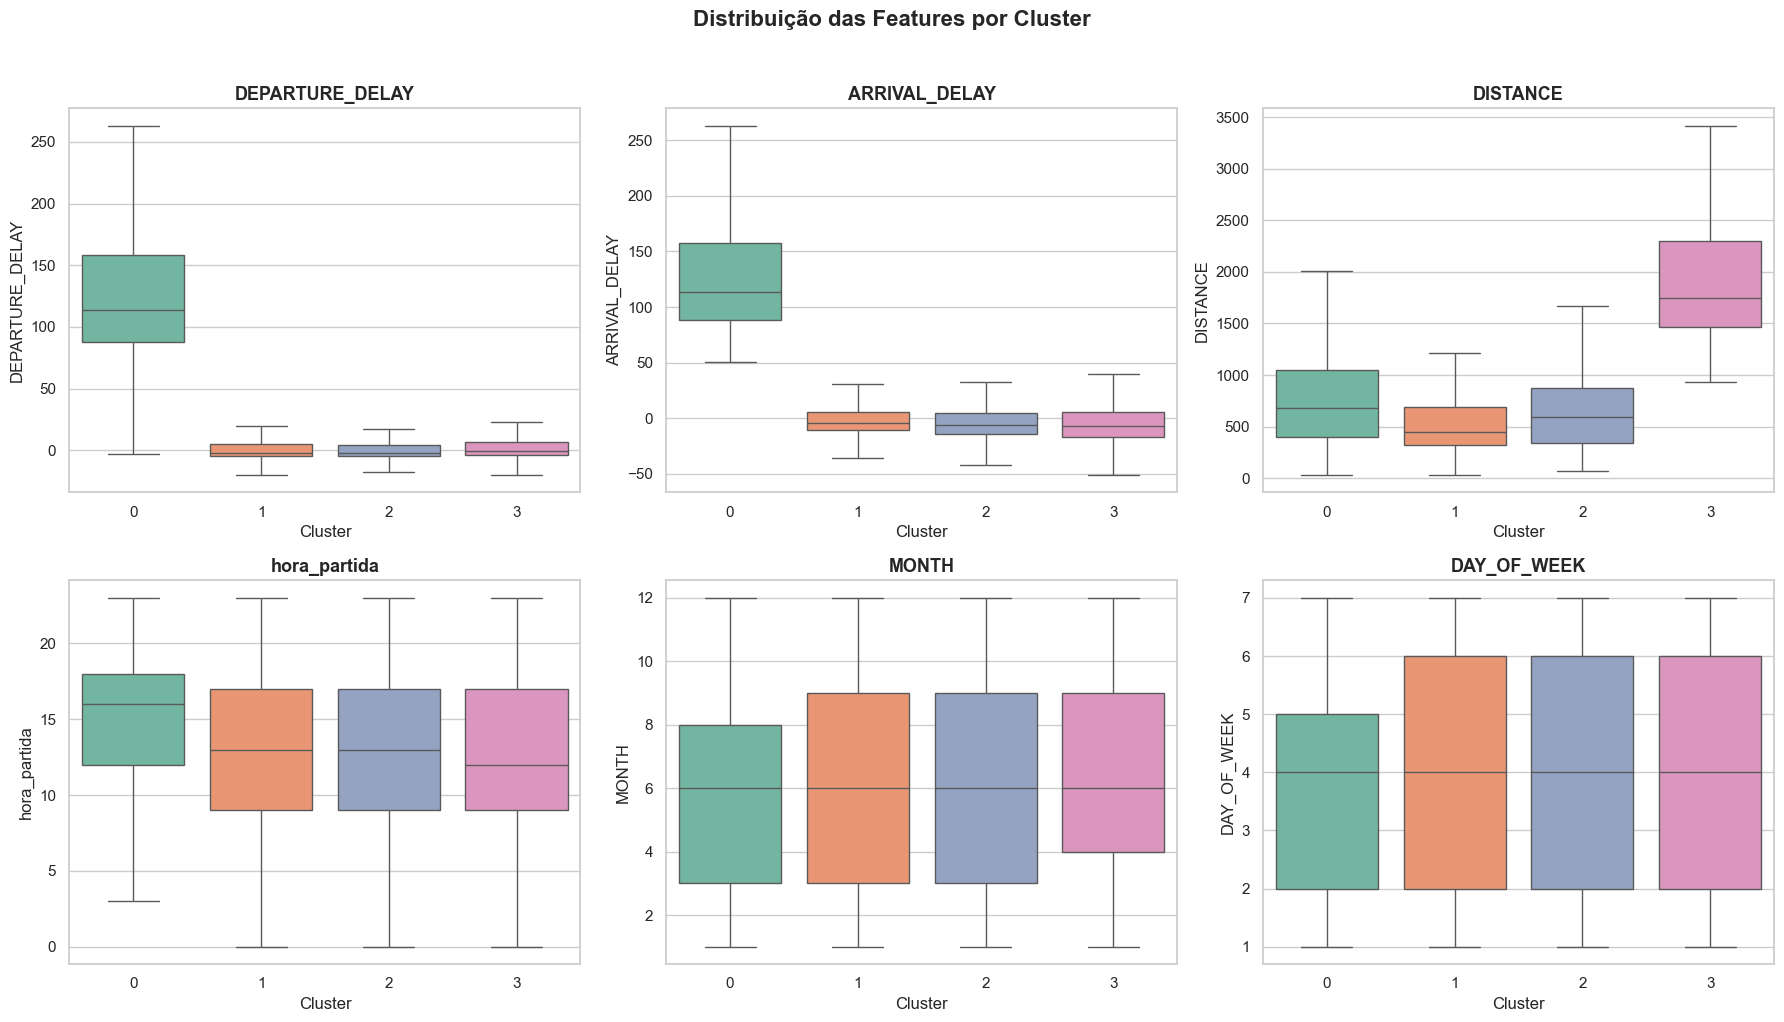

In [14]:
# Boxplots das principais features por cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
main_features = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'DISTANCE', 'hora_partida', 'MONTH', 'DAY_OF_WEEK']

for idx, feat in enumerate(main_features):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df_sample, x='CLUSTER', y=feat, ax=ax, palette='Set2', showfliers=False)
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_xlabel('Cluster')

plt.suptitle('Distribuição das Features por Cluster', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Perfil médio normalizado por cluster
from matplotlib.patches import FancyBboxPatch

cluster_means_norm = df_sample.groupby('CLUSTER')[features_clustering].mean()

# Normalizar entre 0 e 1 para radar
cluster_radar = (cluster_means_norm - cluster_means_norm.min()) / (cluster_means_norm.max() - cluster_means_norm.min())

categories = features_clustering
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

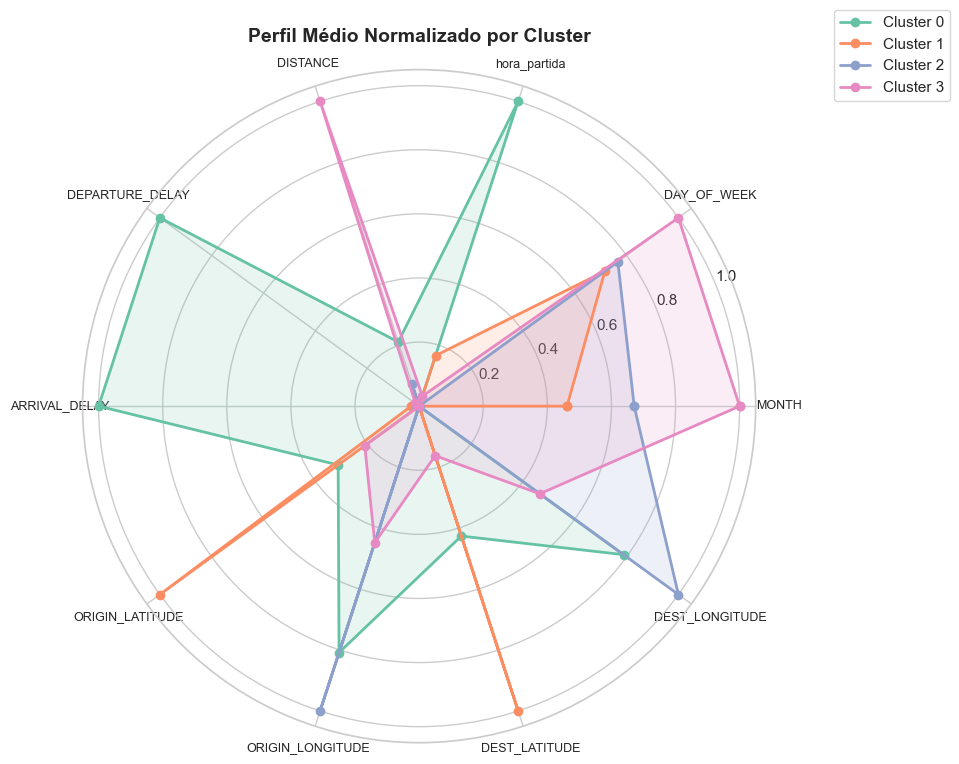

In [16]:
# Visualizando
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = sns.color_palette('Set2', OPTIMAL_K)

for cluster_id in range(OPTIMAL_K):
    values = cluster_radar.loc[cluster_id].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}', color=colors[cluster_id])
    ax.fill(angles, values, alpha=0.15, color=colors[cluster_id])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=9)
ax.set_title('Perfil Médio Normalizado por Cluster', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

### Enriquecimento com dados categóricos

In [17]:
df_enriched = df_cluster.loc[df_sample.index].copy()
df_enriched['CLUSTER'] = df_sample['CLUSTER'].values

In [18]:
print("=== TOP COMPANHIAS AÉREAS POR CLUSTER ===\n")

for c in range(OPTIMAL_K):
    top_airlines = df_enriched[df_enriched['CLUSTER'] == c]['AIRLINE'].value_counts().head(5)
    pct = (top_airlines / top_airlines.sum() * 100).round(1)
    print(f"Cluster {c}:")
    
    for airline, count in top_airlines.items():
        print(f"  {airline}: {count:,} voos ({pct[airline]}%)")

=== TOP COMPANHIAS AÉREAS POR CLUSTER ===

Cluster 0:
  WN: 913 voos (30.2%)
  UA: 598 voos (19.8%)
  EV: 540 voos (17.9%)
  AA: 501 voos (16.6%)
  OO: 472 voos (15.6%)
Cluster 1:
  WN: 6,101 voos (36.6%)
  OO: 5,906 voos (35.4%)
  AS: 2,213 voos (13.3%)
  UA: 1,295 voos (7.8%)
  DL: 1,152 voos (6.9%)
Cluster 2:
  WN: 11,825 voos (27.1%)
  DL: 10,663 voos (24.4%)
  EV: 9,113 voos (20.9%)
  AA: 7,527 voos (17.2%)
  MQ: 4,527 voos (10.4%)
Cluster 3:
  UA: 3,397 voos (25.2%)
  AA: 3,321 voos (24.6%)
  WN: 3,057 voos (22.7%)
  DL: 2,822 voos (20.9%)
  US: 879 voos (6.5%)


In [19]:
print("\n=== DIA DA SEMANA PREDOMINANTE POR CLUSTER ===\n")

for c in range(OPTIMAL_K):
    top_days = df_enriched[df_enriched['CLUSTER'] == c]['dia_semana'].value_counts().head(3)
    pct = (top_days / top_days.sum() * 100).round(1)
    print(f"Cluster {c}: {', '.join([f'{d} ({pct[d]}%)' for d in top_days.index])}")


=== DIA DA SEMANA PREDOMINANTE POR CLUSTER ===

Cluster 0: Segunda (36.3%), Quinta (33.3%), Terça (30.4%)
Cluster 1: Segunda (33.9%), Quinta (33.1%), Quarta (33.0%)
Cluster 2: Quinta (33.4%), Sexta (33.3%), Quarta (33.3%)
Cluster 3: Sexta (33.7%), Quinta (33.2%), Quarta (33.1%)


### Criando as personas

In [20]:
def gerar_personas(df_enriched, cluster_means, optimal_k):
    """Gera descrições de personas baseadas nos perfis dos clusters."""
    
    global_means = df_enriched[features_clustering].mean()
    personas = {}
    
    for c in range(optimal_k):
        df_c = df_enriched[df_enriched['CLUSTER'] == c]
        means = cluster_means.loc[c]
        n_voos = len(df_c)
        pct = n_voos / len(df_enriched) * 100
        
        # Características
        top_airline = df_c['AIRLINE'].value_counts().index[0]
        top_airline_name = df_c['AIRLINE_NAME'].value_counts().index[0]
        avg_dep_delay = means['DEPARTURE_DELAY']
        avg_arr_delay = means['ARRIVAL_DELAY']
        avg_distance = means['DISTANCE']
        avg_hour = means['hora_partida']
        avg_month = means['MONTH']
        
        # Classificações
        delay_level = "alto atraso" if avg_dep_delay > 15 else ("moderado" if avg_dep_delay > 5 else ("pontual" if avg_dep_delay > -3 else "adiantado"))
        distance_level = "longa distância" if avg_distance > 1500 else ("média distância" if avg_distance > 700 else "curta distância")
        period = "madrugada" if avg_hour < 6 else ("manhã" if avg_hour < 12 else ("tarde" if avg_hour < 18 else "noite"))
        season = "inverno" if avg_month <= 2 or avg_month == 12 else ("primavera" if avg_month <= 5 else ("verão" if avg_month <= 8 else "outono"))
        
        persona = {
            'cluster': c,
            'nome': f"Cluster {c}",
            'n_voos': n_voos,
            'percentual': round(pct, 1),
            'distancia_media': round(avg_distance),
            'tipo_distancia': distance_level,
            'atraso_saida_medio': round(avg_dep_delay, 1),
            'atraso_chegada_medio': round(avg_arr_delay, 1),
            'nivel_atraso': delay_level,
            'hora_media': round(avg_hour),
            'periodo': period,
            'mes_medio': round(avg_month, 1),
            'estacao': season,
            'principal_cia': f"{top_airline} ({top_airline_name})",
        }
        
        personas[c] = persona
    
    return personas

In [21]:
personas = gerar_personas(df_enriched, cluster_means, OPTIMAL_K)

In [22]:
print("=" * 80)
print("                    PERSONAS DOS CLUSTERS DE VOOS")  
print("=" * 80)

for c, p in personas.items():
    print(f"""
{'─' * 80}
  CLUSTER {p['cluster']} — "{p['tipo_distancia'].upper()}, {p['periodo'].upper()}, {p['nivel_atraso'].upper()}"
{'─' * 80}
  Voos:           {p['n_voos']:,} ({p['percentual']}% do total)
  Distância:      {p['distancia_media']:,} milhas ({p['tipo_distancia']})
  Atraso saída:   {p['atraso_saida_medio']} min ({p['nivel_atraso']})
  Atraso chegada: {p['atraso_chegada_medio']} min
  Horário:        ~{p['hora_media']}h ({p['periodo']})
  Sazonalidade:   Mês médio {p['mes_medio']} ({p['estacao']})
  Cia principal:  {p['principal_cia']}
""")

                    PERSONAS DOS CLUSTERS DE VOOS

────────────────────────────────────────────────────────────────────────────────
  CLUSTER 0 — "MÉDIA DISTÂNCIA, TARDE, ALTO ATRASO"
────────────────────────────────────────────────────────────────────────────────
  Voos:           4,620 (4.6% do total)
  Distância:      809 milhas (média distância)
  Atraso saída:   136.3 min (alto atraso)
  Atraso chegada: 136.0 min
  Horário:        ~15h (tarde)
  Sazonalidade:   Mês médio 6.0 (verão)
  Cia principal:  WN (Southwest Airlines Co.)


────────────────────────────────────────────────────────────────────────────────
  CLUSTER 1 — "CURTA DISTÂNCIA, TARDE, PONTUAL"
────────────────────────────────────────────────────────────────────────────────
  Voos:           20,223 (20.2% do total)
  Distância:      528 milhas (curta distância)
  Atraso saída:   3.1 min (pontual)
  Atraso chegada: 0.3 min
  Horário:        ~13h (tarde)
  Sazonalidade:   Mês médio 6.1 (verão)
  Cia principal:  WN (South

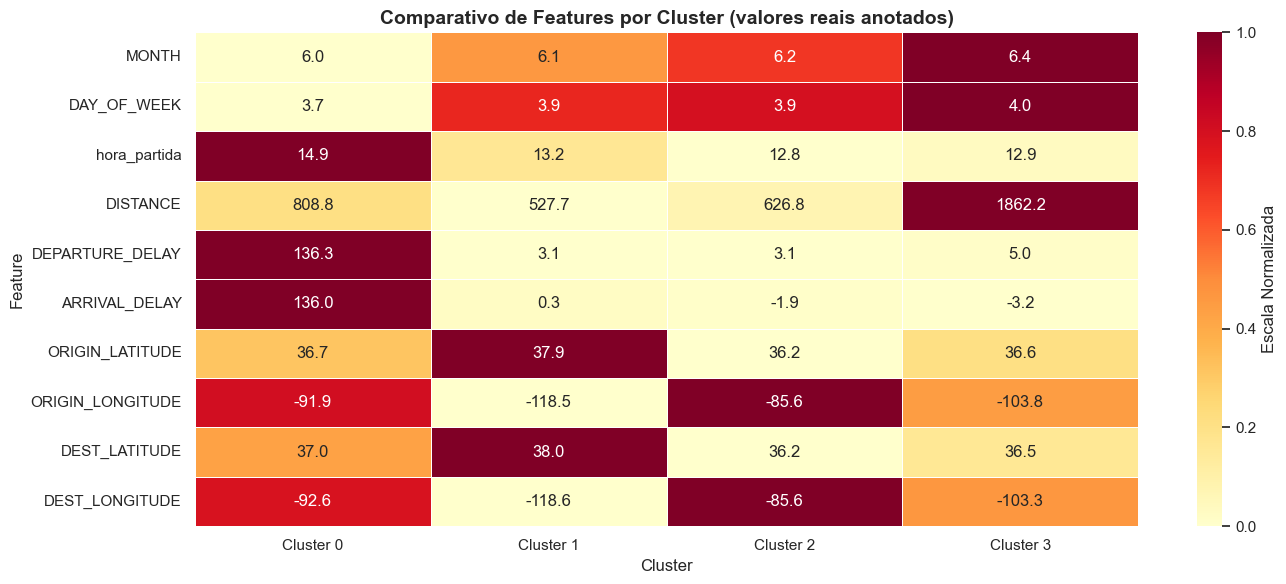

In [23]:
fig, ax = plt.subplots(figsize=(14, 6))

# Heatmap com médias normalizadas
persona_df = pd.DataFrame({
    f"Cluster {c}": cluster_means.loc[c] for c in range(OPTIMAL_K)
})

# Normalizar para melhor visualização
persona_norm = (persona_df - persona_df.min(axis=1).values.reshape(-1, 1)) / \
               (persona_df.max(axis=1).values.reshape(-1, 1) - persona_df.min(axis=1).values.reshape(-1, 1))

sns.heatmap(persona_norm, annot=persona_df.round(1).values, fmt='', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Escala Normalizada'})

ax.set_title('Comparativo de Features por Cluster (valores reais anotados)', fontsize=14, fontweight='bold')
ax.set_ylabel('Feature')
ax.set_xlabel('Cluster')

plt.tight_layout()
plt.show()

### Conclusão